In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

In [2]:
DATA_DIR = Path("./data")
FIG_DIR  = Path("./figures")

In [3]:
# Automatically find files matching the pattern
files = sorted(DATA_DIR.glob("green_tripdata_2026-0*.parquet"))

if not files:
    raise FileNotFoundError(
        f"No parquet files found! Please check DATA_DIR = '{DATA_DIR.resolve()}' "
        "and download green_tripdata_2026-01.parquet and green_tripdata_2026-02.parquet"
    )

print(f"Found {len(files)} file(s):")
for f in files:
    size_mb = f.stat().st_size / 1024**2
    print(f"  {f.name}  ({size_mb:.1f} MB)")

# Merge both months into a single DataFrame
df = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

# Normalise column names to lowercase (casing can vary across years)
df.columns = df.columns.str.lower()

print(f"\n✓ Done: {df.shape[0]:,} rows × {df.shape[1]} columns")

Found 2 file(s):
  green_tripdata_2026-01.parquet  (0.9 MB)
  green_tripdata_2026-02.parquet  (0.9 MB)

✓ Done: 77,645 rows × 21 columns


In [4]:
print(df.dtypes)
df.head(10)

vendorid                          int32
lpep_pickup_datetime     datetime64[us]
lpep_dropoff_datetime    datetime64[us]
store_and_fwd_flag               object
ratecodeid                      float64
pulocationid                      int32
dolocationid                      int32
passenger_count                 float64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
ehail_fee                       float64
improvement_surcharge           float64
total_amount                    float64
payment_type                    float64
trip_type                       float64
congestion_surcharge            float64
cbd_congestion_fee              float64
dtype: object


,vendorid,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,ratecodeid,pulocationid,dolocationid,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.7,...,1.5,7.50,0.0,NaN,1.0,45.20,1.0,1.0,2.75,0.75
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.0,...,0.0,10.20,0.0,NaN,1.0,61.20,1.0,2.0,0.00,0.00
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.5,...,1.5,2.00,0.0,NaN,1.0,46.00,1.0,1.0,0.00,0.00
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.8,...,1.5,0.00,0.0,NaN,1.0,25.05,2.0,1.0,2.75,0.00
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.1,...,0.5,0.00,0.0,NaN,1.0,21.60,2.0,1.0,0.00,0.00
5,2,2026-01-01 00:16:31,2026-01-01 00:33:57,N,1.0,66,88,1.0,2.60,19.8,...,0.5,0.00,0.0,NaN,1.0,25.80,1.0,1.0,2.75,0.75
6,2,2026-01-01 00:08:25,2026-01-01 00:18:15,N,1.0,166,239,1.0,1.35,11.4,...,0.5,3.33,0.0,NaN,1.0,19.98,1.0,1.0,2.75,0.00
7,2,2026-01-01 00:51:18,2026-01-01 00:58:35,N,1.0,41,42,1.0,1.27,9.3,...,0.5,1.00,0.0,NaN,1.0,12.80,1.0,1.0,0.00,0.00
8,2,2026-01-01 00:53:05,2026-01-01 00:56:27,N,5.0,92,92,1.0,0.51,15.0,...,0.0,0.00,0.0,NaN,1.0,16.00,1.0,2.0,0.00,0.00
9,2,2026-01-01 00:19:51,2026-01-01 00:48:36,N,1.0,74,211,1.0,9.06,41.5,...,0.5,0.00,0.0,NaN,1.0,47.50,2.0,1.0,2.75,0.75


In [5]:
# Convert to datetime (usually automatic when reading parquet, but kept for safety)
df["lpep_pickup_datetime"]  = pd.to_datetime(df["lpep_pickup_datetime"])
df["lpep_dropoff_datetime"] = pd.to_datetime(df["lpep_dropoff_datetime"])

# Derive time-based features
df["trip_duration_min"] = (
    (df["lpep_dropoff_datetime"] - df["lpep_pickup_datetime"])
    .dt.total_seconds() / 60          # timedelta → minutes
)

df["pickup_hour"]    = df["lpep_pickup_datetime"].dt.hour
df["pickup_weekday"] = df["lpep_pickup_datetime"].dt.day_name()
df["pickup_month"]   = df["lpep_pickup_datetime"].dt.month
df["pickup_date"]    = df["lpep_pickup_datetime"].dt.date     # used for daily trip counts

print("New columns: trip_duration_min, pickup_hour, pickup_weekday, pickup_month, pickup_date")
print("\nTrip duration stats (including anomalies):")
print(df["trip_duration_min"].describe())



New columns: trip_duration_min, pickup_hour, pickup_weekday, pickup_month, pickup_date

Trip duration stats (including anomalies):
count    77645.000000
mean        20.379427
std         71.041750
min        -10.183333
25%          8.266667
50%         13.083333
75%         20.316667
max       1439.800000
Name: trip_duration_min, dtype: float64


In [6]:
df.head(10)

,vendorid,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,ratecodeid,pulocationid,dolocationid,passenger_count,trip_distance,fare_amount,...,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,trip_duration_min,pickup_hour,pickup_weekday,pickup_month,pickup_date
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.7,...,45.20,1.0,1.0,2.75,0.75,27.300000,0,Thursday,1,2026-01-01
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.0,...,61.20,1.0,2.0,0.00,0.00,48.383333,0,Thursday,1,2026-01-01
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.5,...,46.00,1.0,1.0,0.00,0.00,21.300000,0,Thursday,1,2026-01-01
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.8,...,25.05,2.0,1.0,2.75,0.00,16.200000,0,Thursday,1,2026-01-01
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.1,...,21.60,2.0,1.0,0.00,0.00,18.600000,0,Thursday,1,2026-01-01
5,2,2026-01-01 00:16:31,2026-01-01 00:33:57,N,1.0,66,88,1.0,2.60,19.8,...,25.80,1.0,1.0,2.75,0.75,17.433333,0,Thursday,1,2026-01-01
6,2,2026-01-01 00:08:25,2026-01-01 00:18:15,N,1.0,166,239,1.0,1.35,11.4,...,19.98,1.0,1.0,2.75,0.00,9.833333,0,Thursday,1,2026-01-01
7,2,2026-01-01 00:51:18,2026-01-01 00:58:35,N,1.0,41,42,1.0,1.27,9.3,...,12.80,1.0,1.0,0.00,0.00,7.283333,0,Thursday,1,2026-01-01
8,2,2026-01-01 00:53:05,2026-01-01 00:56:27,N,5.0,92,92,1.0,0.51,15.0,...,16.00,1.0,2.0,0.00,0.00,3.366667,0,Thursday,1,2026-01-01
9,2,2026-01-01 00:19:51,2026-01-01 00:48:36,N,1.0,74,211,1.0,9.06,41.5,...,47.50,2.0,1.0,2.75,0.75,28.750000,0,Thursday,1,2026-01-01


In [7]:
print(df["pickup_month"].value_counts())

pickup_month
1     40258
2     37380
12        4
3         3
Name: count, dtype: int64


In [8]:
df = df[df["pickup_month"].isin([1, 2])] 
print(df["pickup_month"].value_counts())

pickup_month
1    40258
2    37380
Name: count, dtype: int64


In [9]:
# Missing value summary table
missing = (
    df.isnull().sum()
      .rename("count")
      .to_frame()
      .assign(pct=lambda x: (x["count"] / len(df) * 100).round(2))
      .query("count > 0")
      .sort_values("count", ascending=False)
)

if missing.empty:
    print("✓ No missing values")
else:
    print(f"{len(missing)} column(s) contain missing values:")
    print(missing.to_string())

7 column(s) contain missing values:
                      count     pct
ehail_fee             77638  100.00
trip_type             10803   13.91
store_and_fwd_flag    10801   13.91
passenger_count       10801   13.91
ratecodeid            10801   13.91
payment_type          10801   13.91
congestion_surcharge  10801   13.91


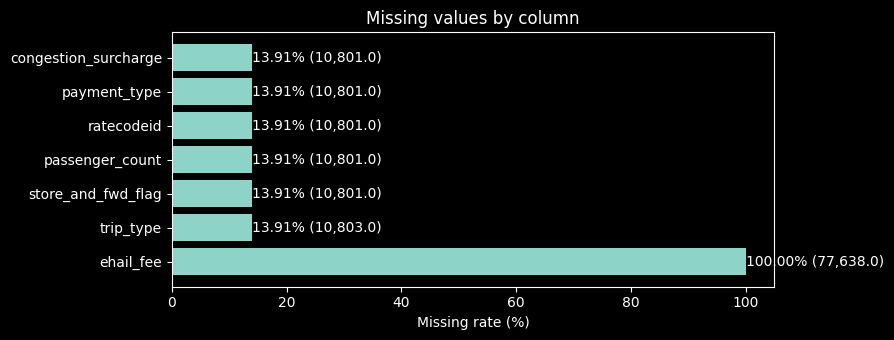

In [10]:
# Visualise missing values (only when there are any)
if not missing.empty:
    fig, ax = plt.subplots(figsize=(9, max(3, len(missing) * 0.5)))
    bars = ax.barh(missing.index, missing["pct"])
    ax.set_xlabel("Missing rate (%)")
    ax.set_title("Missing values by column")
    # Annotate each bar with exact count and percentage
    for bar, (_, row) in zip(bars, missing.iterrows()):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f"{row['pct']:.2f}% ({row['count']:,})",
                va="center", fontsize=10)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "00_missing_values.png", bbox_inches="tight")
    plt.show()
else:
    print("No missing values — skipping plot.")

In [11]:
df = df.drop(columns=["ehail_fee"])

In [12]:
mask_missing = df["passenger_count"].isnull()
print(df[mask_missing]["vendorid"].value_counts())

vendorid
6    7519
2    3132
1     150
Name: count, dtype: int64


In [13]:
before = len(df)
df = df.dropna(subset=["passenger_count"])
after = len(df)

In [14]:
# Anomaly counts before cleaning
checks = {
    "fare_amount < 0"           : df["fare_amount"] < 0,
    "fare_amount == 0"          : df["fare_amount"] == 0,
    "trip_distance == 0"        : df["trip_distance"] == 0,
    "trip_distance > 100 miles" : df["trip_distance"] > 100,
    "passenger_count == 0"      : df["passenger_count"] == 0,
    "trip_duration_min <= 0"    : df["trip_duration_min"] <= 0,
    "trip_duration_min > 180"   : df["trip_duration_min"] > 180,
}

print(f"Total rows: {len(df):,}\n")
print(f"{'Condition':<32} {'Count':>8} {'%':>7}")
print("-" * 52)
for label, mask in checks.items():
    n = mask.sum()
    print(f"{label:<32} {n:>8,} {n/len(df)*100:>6.2f}%")



Total rows: 66,837

Condition                           Count       %
----------------------------------------------------
fare_amount < 0                       225   0.34%
fare_amount == 0                       54   0.08%
trip_distance == 0                  2,540   3.80%
trip_distance > 100 miles               1   0.00%
passenger_count == 0                1,129   1.69%
trip_duration_min <= 0                 44   0.07%
trip_duration_min > 180               265   0.40%


In [15]:
# Clean: create a filtered copy (keep original df for reference)
mask_clean = (
    (df["fare_amount"]        >  0)   &
    (df["tip_amount"]         >= 0)   &
    (df["total_amount"]       >  0)   &
    (df["trip_distance"]      >  0)   &
    (df["trip_distance"]      <= 100) &
    (df["passenger_count"]    >= 1)   &
    (df["trip_duration_min"]  >  0)   &
    (df["trip_duration_min"]  <= 180)
)

df_clean = df[mask_clean].copy()

removed = len(df) - len(df_clean)
print(f"\nBefore cleaning : {len(df):,} rows")
print(f"After cleaning  : {len(df_clean):,} rows")
print(f"Removed         : {removed:,} rows ({removed/len(df)*100:.1f}%)")



Before cleaning : 66,837 rows
After cleaning  : 62,802 rows
Removed         : 4,035 rows (6.0%)


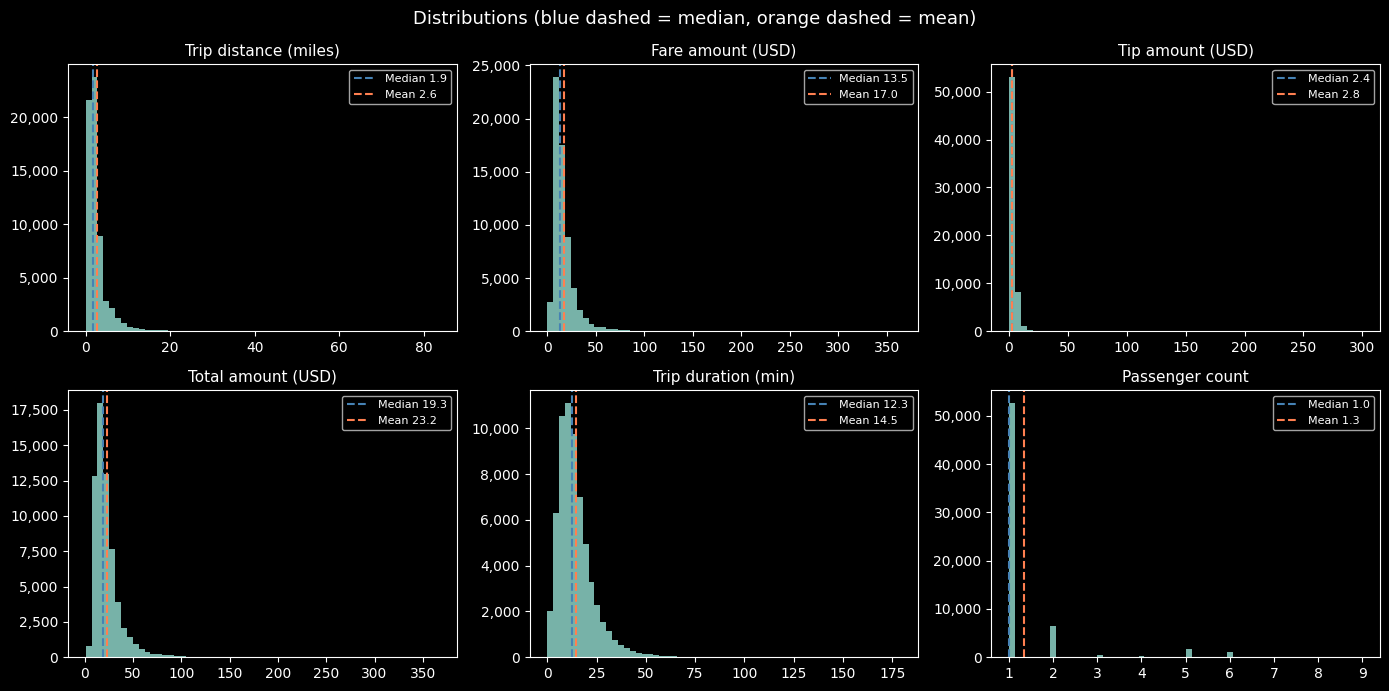

In [16]:
# Distribution plots for 6 key numeric columns
plot_cols = [
    ("trip_distance",     "Trip distance (miles)"),
    ("fare_amount",       "Fare amount (USD)"),
    ("tip_amount",        "Tip amount (USD)"),
    ("total_amount",      "Total amount (USD)"),
    ("trip_duration_min", "Trip duration (min)"),
    ("passenger_count",   "Passenger count"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, (col, label) in zip(axes.flat, plot_cols):
    ax.hist(df_clean[col], bins=60, edgecolor="none", alpha=0.85)
    # Overlay median and mean as vertical lines
    median = df_clean[col].median()
    mean   = df_clean[col].mean()
    ax.axvline(median, color="steelblue", linewidth=1.5, linestyle="--", label=f"Median {median:.1f}")
    ax.axvline(mean,   color="coral",     linewidth=1.5, linestyle="--", label=f"Mean {mean:.1f}")
    ax.set_title(label, fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend(fontsize=8)

fig.suptitle("Distributions (blue dashed = median, orange dashed = mean)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_distributions.png", bbox_inches="tight")
plt.show()


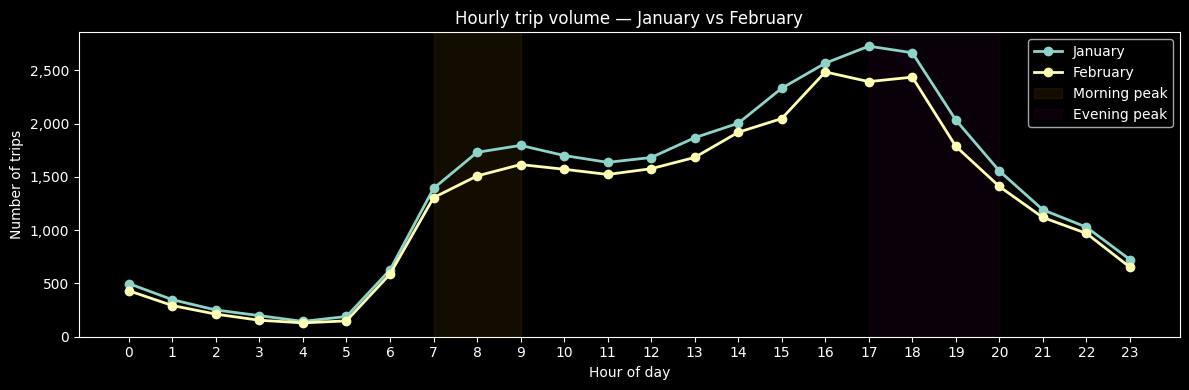

In [ ]:
# Hourly trip volume — January vs February
hourly = (
    df_clean.groupby(["pickup_month", "pickup_hour"])
            .size()
            .reset_index(name="trips")
)

month_labels = {1: "January", 2: "February"}

fig, ax = plt.subplots(figsize=(12, 4))
for month, grp in hourly.groupby("pickup_month"):
    ax.plot(grp["pickup_hour"], grp["trips"],
            marker="o", linewidth=2, label=month_labels.get(month, str(month)))

# Highlight peak periods
ax.axvspan(7, 9,   alpha=0.08, color="orange", label="Morning peak")
ax.axvspan(17, 20, alpha=0.08, color="purple", label="Evening peak")

ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of trips")
ax.set_title("Hourly trip volume — January vs February")
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "02_hourly_volume.png", bbox_inches="tight")
plt.show()
